In [1]:
import os
import math
import random
import cv2
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt

# Main function

In [2]:
def order_points(pts):
    rect = np.zeros((4,2), dtype=np.float32)
    s = pts.sum(axis = 1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis = 1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

In [3]:
def four_point_transform(image, pts):
	rect = order_points(pts)
	(tl, tr, br, bl) = rect
	widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
	widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
	maxWidth = max(int(widthA), int(widthB))
	heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
	heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
	maxHeight = max(int(heightA), int(heightB))
	dst = np.array([
		[0, 0],
		[maxWidth - 1, 0],
		[maxWidth - 1, maxHeight - 1],
		[0, maxHeight - 1]], dtype = "float32")
	M = cv2.getPerspectiveTransform(rect, dst)
	warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
	return warped

# Testing

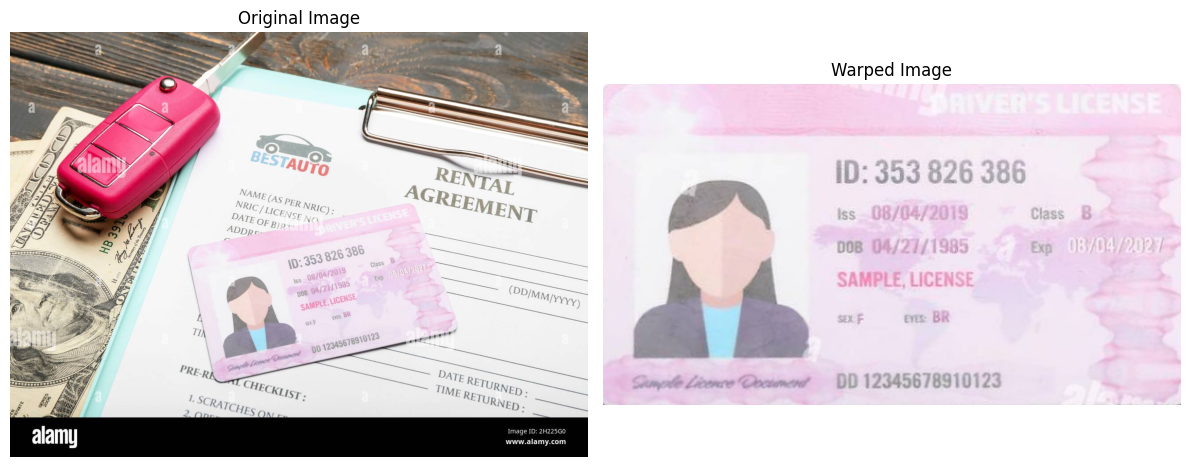

In [4]:
image = cv2.imread('exemple_docs/ex1.jpg')
pts = np.array([(400,488),(906,385),(1000,670),(467,784)], dtype = "float32")

warped = four_point_transform(image, pts)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(image_rgb)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(warped_rgb)
ax2.set_title('Warped Image')
ax2.axis('off')

plt.tight_layout()
plt.show()

# Finding angles

In [5]:
def get_corners_from_mask(mask):
    H_orig, W_orig = mask.shape[:2]

    mask_resized = cv2.resize(mask, (1024, 1024), interpolation=cv2.INTER_NEAREST)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    mask_clean = cv2.morphologyEx(mask_resized, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(contours, key=cv2.contourArea)

    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect)
    box = np.array(box)

    sx = W_orig / 1024.0
    sy = H_orig / 1024.0

    box_orig = box.copy()
    box_orig[:, 0] *= sx
    box_orig[:, 1] *= sy

    return np.int32(box_orig)


In [6]:
mask = cv2.imread('exemple_docs/ex1_mask.png', cv2.IMREAD_GRAYSCALE)
corners = get_corners_from_mask(mask)

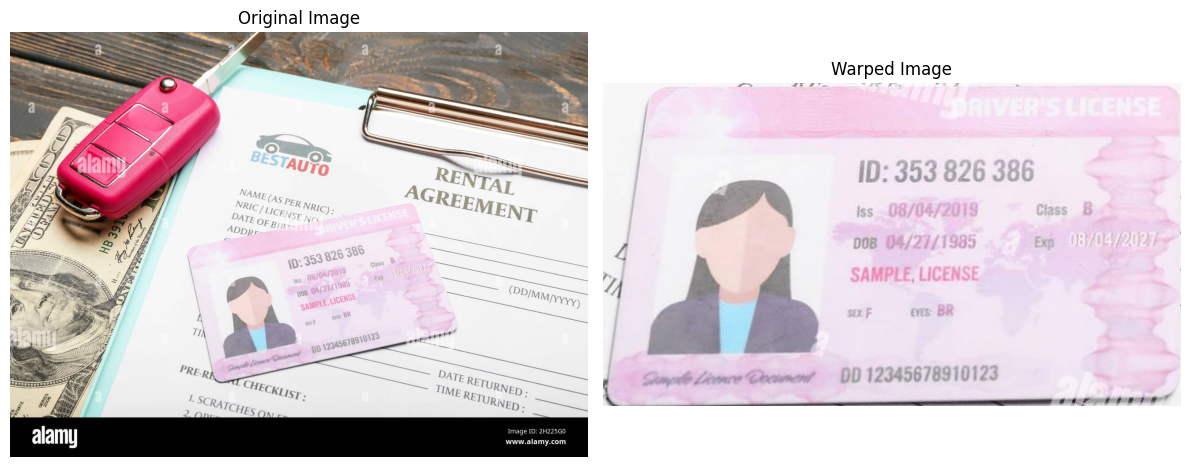

In [7]:
image = cv2.imread('exemple_docs/ex1.jpg')
pts = np.array(corners, dtype = "float32")

warped = four_point_transform(image, pts)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(image_rgb)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(warped_rgb)
ax2.set_title('Warped Image')
ax2.axis('off')

plt.tight_layout()
plt.show()

# Synthetic mask generator

In [8]:
def generate_empty_canvas(min_size=512, max_size=2048):
    H = np.random.randint(min_size, max_size+1)
    W = np.random.randint(min_size, max_size+1)

    canvas = np.zeros((H, W), dtype=np.uint8)
    return canvas

In [9]:
def generate_perspective_corners(doc_w, doc_h, max_shift=0.3):

    tl = np.array([0, 0], dtype=np.float32)
    tr = np.array([doc_w, 0], dtype=np.float32)
    br = np.array([doc_w, doc_h], dtype=np.float32)
    bl = np.array([0, doc_h], dtype=np.float32)

    def shift_point(pt, max_shift_w, max_shift_h):
        dx = np.random.uniform(-max_shift_w, max_shift_w)
        dy = np.random.uniform(-max_shift_h, max_shift_h)
        return pt + np.array([dx, dy])

    max_dx = doc_w * max_shift
    max_dy = doc_h * max_shift

    tl = shift_point(tl, max_dx, max_dy)
    tr = shift_point(tr, max_dx, max_dy)
    br = shift_point(br, max_dx, max_dy)
    bl = shift_point(bl, max_dx, max_dy)

    corners = np.array([tl, tr, br, bl], dtype=np.float32)
    return corners

In [11]:
def generate_document_mask(min_size=512, max_size=2048, max_shift=0.3, allow_crop=False):
    """
    Генерирует маску документа с возможностью выхода углов за пределы изображения
    
    Args:
        allow_crop: если True, документ может частично выходить за границы
    """
    H = np.random.randint(min_size, max_size+1)
    W = np.random.randint(min_size, max_size+1)
    canvas = np.zeros((H, W), dtype=np.uint8)

    # Увеличим диапазон размеров документа
    doc_w = np.random.randint(int(W*0.25), int(W*0.75))
    doc_h = np.random.randint(int(H*0.25), int(H*0.75))

    corners = generate_perspective_corners(doc_w, doc_h, max_shift=max_shift)

    if allow_crop and np.random.rand() < 0.3:  # 30% шанс обрезки
        # Позволяем offset быть отрицательным или выходить за границы

        margin_x = int(doc_w * 0.2)    return canvas, corners_original.astype(np.float32)

        margin_y = int(doc_h * 0.2)

        offset_x = np.random.randint(-margin_x, max(1, W - doc_w + margin_x))    cv2.fillPoly(canvas, [corners_int], color=1)

        offset_y = np.random.randint(-margin_y, max(1, H - doc_h + margin_y))    corners_int = corners.astype(np.int32)

    else:    # fillPoly автоматически обрежет по границам canvas

        # Документ полностью в кадре

        offset_x = np.random.randint(0, max(1, W - doc_w))    corners_original = corners.copy()

        offset_y = np.random.randint(0, max(1, H - doc_h))    # Сохраняем оригинальные координаты (могут быть < 0 или > size)

        
    corners += np.array([offset_x, offset_y])

SyntaxError: invalid syntax (714025691.py, line 23)

In [ ]:
mask, corners = generate_document_mask()
print("Corners:\n", corners)
print("Mask shape:", mask.shape)

import matplotlib.pyplot as plt
plt.imshow(mask, cmap='gray')
plt.show()

## Generate dataset

In [ ]:
class SyntheticMaskDataset(Dataset):
    def __init__(self, n_samples=10000, out_size=512, allow_crop=False):
        self.n_samples = n_samples
        self.out_size = out_size
        self.allow_crop = allow_crop
        self.to_tensor = T.Compose([
            T.ToTensor(),
        ])

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        canvas, corners = generate_document_mask(allow_crop=self.allow_crop)

        H_orig, W_orig = canvas.shape
        mask_resized = cv2.resize(canvas, (self.out_size, self.out_size), interpolation=cv2.INTER_NEAREST)

        # Ensure mask is float32 in range [0, 1] for consistency
        mask_resized = mask_resized.astype(np.float32)

        # Масштабируем координаты пропорционально
        scale_x = self.out_size / W_orig
        scale_y = self.out_size / H_orig
        
        corners_scaled = corners.copy()
        corners_scaled[:, 0] = corners_scaled[:, 0] * scale_x
        corners_scaled[:, 1] = corners_scaled[:, 1] * scale_y
        

        # Нормализуем к размеру out_size        return x, y

        # Значения могут быть < 0 или > 1 для углов за границами!

        target = corners_scaled / np.array([self.out_size, self.out_size], dtype=np.float32)        y = torch.from_numpy(target.reshape(-1)).float()

                x = self.to_tensor(mask_resized)

        # Ограничиваем экстремальные значения для стабильности обучения
        target = np.clip(target, -0.5, 1.5)

# Model

In [ ]:
class CornerNet(nn.Module):

    def __init__(self, pretrained=False, dropout=0.3):
        super().__init__()
        m = models.resnet18(pretrained=pretrained)

        m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.encoder = nn.Sequential(*list(m.children())[:-1])

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 8)
            # No Sigmoid - allow predictions outside [0,1] for out-of-bounds corners
        )

    def forward(self, x):
        f = self.encoder(x)
        out = self.head(f)
        return out

In [ ]:
def train_corner_net(device='cuda' if torch.cuda.is_available() else 'cpu',
                     epochs=15, batch_size=16, lr=1e-3, samples=8000, val_split=0.1,
                     out_size=512, save_path='models/corner_net.pth'):

    # 1. Dataset
    dataset = SyntheticMaskDataset(n_samples=samples, out_size=out_size, allow_crop=True)
    val_n = int(len(dataset) * val_split)
    train_n = len(dataset) - val_n
    train_set, val_set = random_split(dataset, [train_n, val_n])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    # 2. Модель, критерий, оптимизатор
    model = CornerNet(pretrained=False).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = float('inf')

    # 3. Цикл обучения
    for epoch in range(1, epochs+1):
        model.train()
        running_train = 0.0
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch} train"):
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()

            running_train += loss.item() * x.size(0)

        train_loss = running_train / train_n

        # 4. Валидация
        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                loss = criterion(pred, y)
                running_val += loss.item() * x.size(0)

        val_loss = running_val / val_n
        print(f"Epoch {epoch}: train_loss={train_loss:.6f}, val_loss={val_loss:.6f}")

        # 5. Сохранение лучшей модели
        if val_loss < best_val:
            best_val = val_loss
            torch.save({'model_state': model.state_dict(), 'out_size': out_size}, save_path)
            print(f"Saved best model: {save_path}")

    return model

In [ ]:
def predict_corners_from_mask(model, mask, device='cpu', out_size=512):
    H_orig, W_orig = mask.shape[:2]
    
    # Resize mask to out_size
    m = cv2.resize(mask, (out_size, out_size), interpolation=cv2.INTER_NEAREST)
    
    # Normalize mask: binary mask should have values 0 and 1 (not 0 and 255)
    # This matches the training data format
    if m.max() > 1:
        m = m / 255.0
    
    inp = torch.from_numpy(m).float().to(device)[None,None]

    with torch.no_grad():
        pred = model(inp)[0].cpu().numpy()  # shape (8,) normalized coords
    pred = pred.reshape(4, 2)

    # Scale coordinates back to original image size
    # pred is normalized by out_size, so multiply by original size
    pred[:, 0] *= W_orig
    pred[:, 1] *= H_orig
    

    # Optionally clip to valid range (or keep raw for debugging)    return pred.astype(np.float32)

    # pred[:, 0] = np.clip(pred[:, 0], 0, W_orig - 1)
    # pred[:, 1] = np.clip(pred[:, 1], 0, H_orig - 1)

In [ ]:
MODEL_PATH = "models/corner_net_v2.pth"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if not os.path.exists(MODEL_PATH):
    print("Training model...")
    train_corner_net(
        device=device,
        epochs=1,
        batch_size=16,      # для 512x512 лучше меньше
        lr=1e-3,
        samples=4000,
        out_size=512,       # наши маски 512x512
        save_path=MODEL_PATH
    )
# load model
chk = torch.load(MODEL_PATH, map_location=device)
model = CornerNet(pretrained=False).to(device)
model.load_state_dict(chk['model_state'])
out_size = chk.get('out_size', 512)

In [ ]:
# Example: use your mask from file and original image
mask = cv2.imread('exemple_docs/ex1_mask.png', cv2.IMREAD_GRAYSCALE)
image = cv2.imread('exemple_docs/ex1.jpg')

corners = predict_corners_from_mask(model, mask, device=device, out_size=out_size)  # shape (4,2)

# order points and crop (use your four_point_transform)
pts = np.array(corners, dtype='float32')
pts = order_points(pts)            # tl,tr,br,bl
warped = four_point_transform(image, pts)   # reuse your function

# visualize (requires matplotlib)
try:
    import matplotlib.pyplot as plt
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,6))
    ax1.imshow(image_rgb); ax1.set_title('Original'); ax1.axis('off')
    ax2.imshow(warped_rgb); ax2.set_title('Warped'); ax2.axis('off')
    plt.show()
except Exception as e:
    print("Visualization skipped:", e)

In [ ]:
corners

In [ ]:
print(pts)